 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Tomas Wynne                <br>
Student Number : L00196526                  <br>
Due Date       : 12th May 2026              <br>
Assignment     : CA2                        <br>
Module         : AI for Vision and NLP      <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [21]:
%pip install -r requirements.txt
!python -m spacy download en_core_web_sm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 12.8/12.8 MB 89.1 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [22]:
import os
import cv2
import pymupdf
import json
import pandas as pd
import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

import pytesseract

# regular expression
import re

# Variable Assignments

In [23]:
# Load NLP Spacy model
nlp = spacy.load("en_core_web_sm")

# Data files origin folder
DATA_FOLDER = "data"

# Results output folder
output_json = "document_analysis_results.json"

# Tesseract Path
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Supported extensions
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]
PDF_EXTENSIONS = [".pdf"]

# Support Functions

In [24]:
def pdf_to_images(pdf_path):
    doc = pymupdf.open(pdf_path)

    images = []

    filename = os.path.splitext(os.path.basename(pdf_path))[0]

    for page_number, page in enumerate(doc):

        # Convert page to image
        pix = page.get_pixmap(dpi=400)

        # Convert pixmap to numpy array
        img_data = np.frombuffer(
            pix.samples,
            dtype=np.uint8
        )

        image = img_data.reshape(
            pix.height,
            pix.width,
            pix.n
        )

        # Convert RGBA to RGB if needed
        if pix.n == 4:
            image = cv2.cvtColor(
                image,
                cv2.COLOR_RGBA2RGB
            )

        images.append({
            "page": page_number + 1,
            "image": image,
            "source": filename
        })

    return images

# NLP

## NLP Functions

In [ ]:
def load_image(path):
    image = cv2.imread(path)
    if image is None:
        raise ValueError(f"Could not load image: {path}")
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image_rgb


def preprocess_image(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Noise reduction
    blur = cv2.GaussianBlur(gray,(5,5),0)
    # Adaptive thresholding
    thresh = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY_INV,11,8)

    return gray, blur, thresh


# Makes a token out of the lemma of every word in the document that is not a stop word, punctuation or a space
def preprocess_text(text):
    document = nlp(text)
    tokens = []

    for token in document:
        if not token.is_stop and not token.is_punct and not token.is_space:
            tokens.append(token.lemma_.lower())
    
    return tokens, document


# Returns Named Entities
def get_entities(document):

    entities = []
    for ent in document.ents:
        entities.append({
            "text": ent.text,
            "label": ent.label_
        })

    return entities


def get_tfidf(tokens, top_n=15):
    clean_text = " ".join(tokens)

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([clean_text])
    feature_names = vectorizer.get_feature_names_out()

    scores = tfidf_matrix.toarray()[0]
    features = list(zip(feature_names, scores))

    # Sort highest first
    features = sorted(features, key=lambda x: x[1], reverse=True)

    top_features = []

    for word, score in features[:top_n]:
        top_features.append({
            "word": word,
            "score": float(score)
        })

    return top_features


def process_image(image, filename, page_number=1):

    print(f"\nProcessing: {filename} | Page: {page_number}")

    # Preprocess image
    gray, blur, thresh = preprocess_image(image)

    # OCR
    text = pytesseract.image_to_string(thresh)

    # NLP preprocessing
    tokens, document = preprocess_text(text)

    # Entities
    entities = get_entities(document)

    # TF-IDF
    keywords = get_tfidf(tokens)

    # Store results
    result = {
        "filename": filename,
        "page": page_number,
        "raw_text": text,
        "clean_tokens": tokens,
        "named_entities": entities,
        "top_keywords": keywords
    }

    return result, gray, thresh

## Document Processing

In [ ]:
# Used chatgpt to assist with laying out the file intake and document sorting

all_results = []

# Optional preview images
preview_images = []

# Loop through all files
for file in os.listdir(DATA_FOLDER):

    file_path = os.path.join(DATA_FOLDER, file)

    extension = os.path.splitext(file)[1].lower()

    # PDF Files
    if extension in PDF_EXTENSIONS:

        print(f"\nDetected PDF: {file}")
        pdf_images = pdf_to_images(file_path)

        for page_data in pdf_images:
            image = page_data["image"]

            result, gray, thresh = process_image(image,file,page_data["page"])

            all_results.append(result)

            preview_images.append({
                "filename": file,
                "page": page_data["page"],
                "gray": gray,
                "thresh": thresh
            })


    # Image Files
    elif extension in IMAGE_EXTENSIONS:

        print(f"\nDetected Image: {file}")

        image = load_image(file_path)

        result, gray, thresh = process_image(image,file,page_number=1)

        all_results.append(result)

        preview_images.append({
            "filename": file,
            "page": 1,
            "gray": gray,
            "thresh": thresh
        })


    else:

        print(f"Skipping unsupported file: {file}")


# EXPORT JSON RESULTS
with open(output_json, "w", encoding="utf-8") as file:
    json.dump(
        all_results,
        file,
        indent=4,
        ensure_ascii=False
    )

print(f"\nResults exported to: {output_json}")



print("\n================================================")
print("SAMPLE RESULTS")
print("================================================")

for result in all_results:

    print(f"\nFILE: {result['filename']}")
    print(f"PAGE: {result['page']}")

    print("\n--- RAW TEXT PREVIEW ---")
    print("------------------------")
    print(result["raw_text"][:500])

    print("\n--- TOP KEYWORDS ---")
    print("--------------------")
    for keyword in result["top_keywords"][:10]:
        print(f"{keyword['word']} : {keyword['score']:.4f}")

    print("\n--- NAMED ENTITIES ---")
    print("----------------------")
    for entity in result["named_entities"][:10]:
        print(f"{entity['text']} ({entity['label']})")


Detected PDF: BDA_CA2_Technical_Report_pg4.pdf

Processing: BDA_CA2_Technical_Report_pg4.pdf | Page: 1

Detected Image: Blue Prince Screenshot.png

Processing: Blue Prince Screenshot.png | Page: 1

Detected Image: census.jpeg

Processing: census.jpeg | Page: 1

Detected Image: Screenshot 2025-10-07 132823.png

Processing: Screenshot 2025-10-07 132823.png | Page: 1

Detected PDF: Using_Behavioural_Skills_Training_with_Healthcare_page_2.pdf

Processing: Using_Behavioural_Skills_Training_with_Healthcare_page_2.pdf | Page: 1

Results exported to: document_analysis_results.json

SAMPLE RESULTS

FILE: BDA_CA2_Technical_Report_pg4.pdf
PAGE: 1

--- RAW TEXT PREVIEW ---
------------------------
IV. RESULTS AND ANALYSIS
A. Exploratory Data Analysis (EDA) Findings
Prior to modeling, a 1% sample of the 24-million-

record dataset was analyzed. Key observations in-
cluded:

e Feature Correlation: A
correlation was

strong linear

observed between
trip_distance and fare_amount.
However, trip _durat

In [35]:
# Save to Dataframe
results_df = pd.DataFrame(all_results)

print("\n==========================")
print("DATAFRAME OVERVIEW")
print("==========================")

display(results_df.head())


DATAFRAME OVERVIEW


,filename,page,raw_text,clean_tokens,named_entities,top_keywords
0,BDA_CA2_Technical_Report_pg4.pdf,1,IV. RESULTS AND ANALYSIS\nA. Exploratory Data ...,"[iv, results, analysis, a., exploratory, data,...","[{'text': 'EDA', 'label': 'ORG'}, {'text': '1%...","[{'word': 'trip', 'score': 0.32245846375500836..."
1,Blue Prince Screenshot.png,1,THE SOIL SURVEY\n\nOne of the first tasks I un...,"[soil, survey, task, undertake, groundskeeper,...","[{'text': 'One', 'label': 'CARDINAL'}, {'text'...","[{'word': 'soil', 'score': 0.5126145946300565}..."
2,census.jpeg,1,"Form A-CENSUS OF THE IRISH FREE STATE, 1926.\n...","[form, census, irish, free, state, 1926, read,...","[{'text': '1926', 'label': 'DATE'}, {'text': '...","[{'word': 'ee', 'score': 0.16666666666666666},..."
3,Screenshot 2025-10-07 132823.png,1,Free Web/Google\n\nFee\Web/Library/Databases\n...,"[free, web, google, fee\web, library, database...","[{'text': 'Wikipedia', 'label': 'ORG'}, {'text...","[{'word': 'content', 'score': 0.39440531887330..."
4,Using_Behavioural_Skills_Training_with_Healthc...,1,"Behav. Sci. 2025, 15, 870\n\n8 of 21\n\ninterv...","[behav, sci, 2025, 15, 870, 8, 21, interventio...","[{'text': 'Behav', 'label': 'PERSON'}, {'text'...","[{'word': 'change', 'score': 0.289121654791456..."


# Vision

## Sub Heading 1

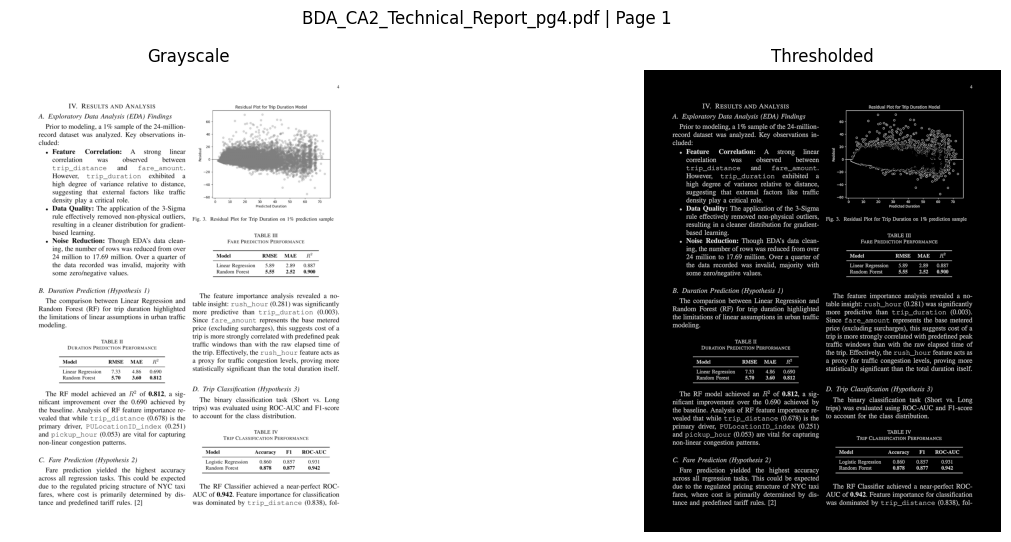

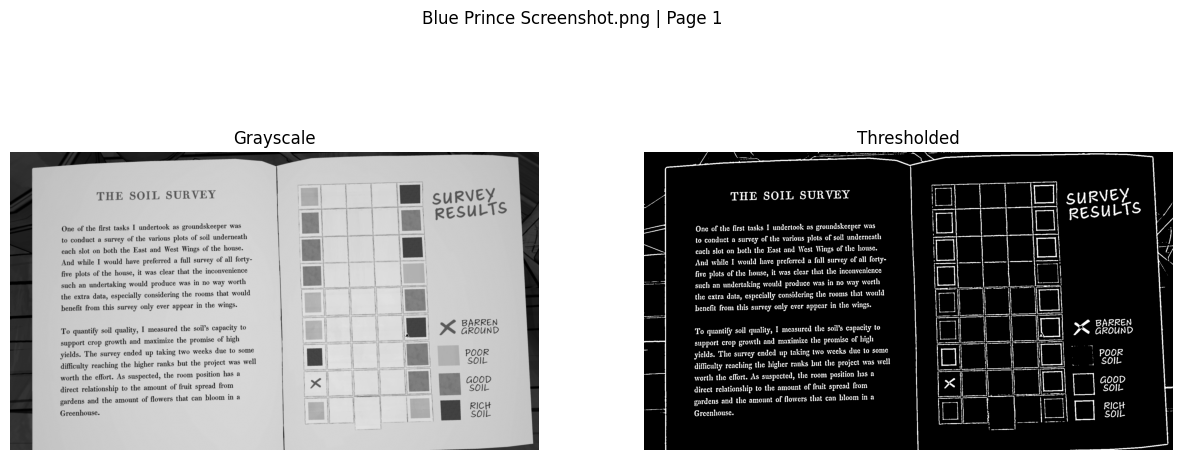

'\n# Display image\nplt.figure(figsize=(18,6))\n\n# Grayscale\nplt.subplot(1,3,1)\nplt.imshow(gray, cmap=\'gray\')\nplt.title("Grayscale")\nplt.axis("off")\n\n# Blurred\nplt.subplot(1,3,2)\nplt.imshow(blur, cmap=\'gray\')\nplt.title("Noise Reduction (Blur)")\nplt.axis("off")\n\n# Thresholded\nplt.subplot(1,3,3)\nplt.imshow(thresh, cmap=\'gray\')\nplt.title("Adaptive Threshold")\nplt.axis("off")\n\nplt.show()\n\n\n# Bounding Boxes\nh, w, c = image_rgb.shape\nboxes = pytesseract.image_to_boxes(image_rgb)\nfor b in boxes.splitlines():\n    b = b.split(\' \')\n    image_boxed = cv2.rectangle(image_rgb, (int(b[1]), h - int(b[2])), (int(b[3]), h - int(b[4])), (0, 255, 0), 2) #OpenCV is in Blue, Green, Red format.\n\nplt.imshow(image_boxed)\nplt.axis("off")\nplt.show()\n\n\n# Detect edges in image\nedges = cv2.Canny(thresh, 50, 150)\n\n# Display edges\nplt.figure(figsize=(12,12))\nplt.imshow(edges, cmap=\'gray\')\nplt.title("Edge Detection (Canny)")\nplt.axis("off")\nplt.show()\n\n# Find cont

In [ ]:
for preview in preview_images:

    plt.figure(figsize=(15, 6))

    plt.suptitle(
        f"{preview['filename']} | "
        f"Page {preview['page']}"
    )

    # Grayscale
    plt.subplot(1, 2, 1)
    plt.imshow(preview["gray"], cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    # Threshold
    plt.subplot(1, 2, 2)
    plt.imshow(preview["thresh"], cmap="gray")
    plt.title("Thresholded")
    plt.axis("off")

    plt.show()


#########################
### NEEDS UPDATING ######
#########################

'''
# Display image
plt.figure(figsize=(18,6))

# Grayscale
plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

# Blurred
plt.subplot(1,3,2)
plt.imshow(blur, cmap='gray')
plt.title("Noise Reduction (Blur)")
plt.axis("off")

# Thresholded
plt.subplot(1,3,3)
plt.imshow(thresh, cmap='gray')
plt.title("Adaptive Threshold")
plt.axis("off")

plt.show()

''''''
# Bounding Boxes
h, w, c = image_rgb.shape
boxes = pytesseract.image_to_boxes(image_rgb)
for b in boxes.splitlines():
    b = b.split(' ')
    image_boxed = cv2.rectangle(image_rgb, (int(b[1]), h - int(b[2])), (int(b[3]), h - int(b[4])), (0, 255, 0), 2) #OpenCV is in Blue, Green, Red format.

plt.imshow(image_boxed)
plt.axis("off")
plt.show()
''''''

# Detect edges in image
edges = cv2.Canny(thresh, 50, 150)

# Display edges
plt.figure(figsize=(12,12))
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis("off")
plt.show()

# Find contours from edge image
contours, hierarchy = cv2.findContours(
    edges,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

print(f"\nNumber of contours detected: {len(contours)}")

# Create copy for drawing
contour_image = image_rgb.copy()

# Loop through contours
for contour in contours:

    # Ignore tiny contours
    area = cv2.contourArea(contour)

    if area > 1000:

        # Get bounding rectangle
        x, y, w, h = cv2.boundingRect(contour)

        # Draw rectangle
        cv2.rectangle(
            contour_image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            3
        )

# Display detected regions
plt.figure(figsize=(15,15))
plt.imshow(contour_image)
plt.title("Detected Document Regions")
plt.axis("off")
plt.show()
'''

# Multi-modal

## Sub Heading 1

In [ ]:
# code here

# Final Output

In [ ]:
# code

# Draft